In [3]:
import pandas as pd
import requests
import numpy as np
from datetime import datetime, timedelta
import time
import yfinance as yf

btc = yf.download("BTC-USD", start="2025-10-01", end="2025-10-23", interval="1h")
btc = btc.reset_index()[["Datetime", "Close"]]
btc.rename(columns={"Datetime": "window", "Close": "price"}, inplace=True)
btc["window"] = pd.to_datetime(btc["window"])

API_KEY = "0e30c2fd9f294f21b216b290a6edd700"
def fetch_newsapi_news(query="bitcoin", start_date="2025-10-01", end_date="2025-10-23"):
    base_url = "https://newsapi.org/v2/everything"
    all_articles = []
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end = datetime.strptime(end_date, "%Y-%m-%d")
    delta = timedelta(days=1)
    while start <= end:
        from_str = start.strftime("%Y-%m-%d")
        to_str = (start + delta).strftime("%Y-%m-%d")
        params = {
            "q": query,
            "from": from_str,
            "to": to_str,
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 100,
            "apiKey": API_KEY
        }
        try:
            r = requests.get(base_url, params=params, timeout=10)
            data = r.json()
            if "articles" in data and data["articles"]:
                all_articles.extend(data["articles"])
        except Exception as e:
            print(f"Ошибка {e} на дате {from_str}")
        start += delta
        time.sleep(0.5)

    df = pd.DataFrame(all_articles)[["title", "description", "content", "publishedAt"]]
    df["text"] = df[["title", "description", "content"]].astype(str).agg(". ".join, axis=1)
    df["publishedAt"] = pd.to_datetime(df["publishedAt"], errors="coerce")
    df.dropna(subset=["text", "publishedAt"], inplace=True)
    return df

news_df = fetch_newsapi_news("bitcoin", "2025-10-01", "2025-10-23")
print(len(news_df))
print(news_df.head())

C:\Users\peche\AppData\Local\Temp\ipykernel_14100\3327870856.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2025-10-01", end="2025-10-23", interval="1h")
[*********************100%***********************]  1 of 1 completed


2149
                                               title  \
0  Why BlackRock's Bitcoin ETF proves 'ETFs are n...   
1  ‘Horse has left the barn:’ ETHZilla bets big o...   
2  Betting markets like Kalshi see the government...   
3  Hackers say they have deleted children’s pictu...   
4  Will a Europe-US BTC reserve race actually hap...   

                                         description  \
0                                               None   
1  ETHZilla CEO McAndrew Rudisill told Cointelegr...   
2  Betting markets like Kalshi see the government...   
3  Joe Tidy reports: Hackers who attempted to ext...   
4  Swedish opposition MPs from the Sweden Democra...   

                                             content  \
0  If you click 'Accept all', we and our partners...   
1  ETHZilla CEO McAndrew Rudisill has revealed he...   
2  Reality must take precedence over public relat...   
3  Hackers who attempted to extort a nursery chai...   
4  Swedish opposition MPs from the Sweden

In [5]:
news_df.to_csv("news_with_context.csv", index=False, encoding="utf-8")

In [12]:
news_df["hour"] = news_df["publishedAt"].dt.floor("H")
news_hourly = news_df.groupby("hour").size().reset_index(name="news_count")

btc_news = pd.merge(btc, news_hourly, how="left", left_on="window", right_on="hour")
btc_news.drop(columns="hour", inplace=True)
btc_news["news_count"] = btc_news["news_count"].fillna(0)

print(btc_news.columns)

Index(['window', 'price', 'news_count'], dtype='object')


C:\Users\peche\AppData\Local\Temp\ipykernel_14100\3489236241.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  news_df["hour"] = news_df["publishedAt"].dt.floor("H")


In [17]:
import joblib
model_1 = joblib.load('../second_training/sentiment_model.pkl')
tfidf_1 = joblib.load('../second_training/tfidf_vectorizer.pkl')
model_2 = joblib.load('../training/sentiment_model_1.pkl')
tfidf_2 = joblib.load('../training/tfidf_vectorizer_1.pkl')
news_df_copy = news_df.copy()

X1 = tfidf_1.transform(news_df_copy["text"])
X2 = tfidf_2.transform(news_df_copy["text"])

news_df_copy["sentiment_1"] = model_1.predict(X1)
news_df_copy["sentiment_2"] = model_2.predict(X2)

mapping = {"positive": 1, "neutral": 0, "negative": -1, "irrelevant": 0}
news_df_copy["sentiment_1"] = news_df_copy["sentiment_1"].str.lower().map(mapping)
news_df_copy["sentiment_2"] = news_df_copy["sentiment_2"].str.lower().map(mapping)
print(news_df_copy.columns)

Index(['title', 'description', 'content', 'publishedAt', 'text', 'window',
       'embedding', 'hour', 'sentiment_1', 'sentiment_2'],
      dtype='object')


In [18]:
news_df_copy["window"] = news_df_copy["publishedAt"].dt.floor("1H")

sentiment_hourly = (
    news_df_copy.groupby("window")[["sentiment_1", "sentiment_2"]]
    .mean()
    .reset_index()
)

data_merge = pd.merge(btc, sentiment_hourly, on="window", how="inner")
data_merge["price_change_6h"] = (data_merge["price"].shift(-6) / data_merge["price"] - 1) * 100

C:\Users\peche\AppData\Local\Temp\ipykernel_14100\1905588451.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  news_df_copy["window"] = news_df_copy["publishedAt"].dt.floor("1H")


In [21]:
from scipy.stats import pearsonr

corr_df = data_merge[["sentiment_1", "sentiment_2", "price_change_6h"]].dropna()

corr1, _ = pearsonr(corr_df["sentiment_1"].dropna(), corr_df["price_change_6h"].dropna())
corr2, _ = pearsonr(corr_df["sentiment_2"].dropna(), corr_df["price_change_6h"].dropna())

print(f"Correlation sentiment_1 vs price_change_6h: {corr1:.3f}")
print(f"Correlation sentiment_2 vs price_change_6h: {corr2:.3f}")

Correlation sentiment_1 vs price_change_6h: -0.105
Correlation sentiment_2 vs price_change_6h: 0.079


In [23]:
maxx_lag = 6
result_1 = []
result_2 = []

for lag in range(-maxx_lag, maxx_lag + 1):
    shifted_1 = data_merge["sentiment_1"].shift(lag)
    shifted_2 = data_merge["sentiment_2"].shift(lag)
        
    corr_df = pd.DataFrame({
        "sentiment_1": shifted_1,
        "sentiment_2": shifted_2,
        "price": data_merge["price"]
    }).dropna()

    corr1, _ = pearsonr(corr_df["sentiment_1"], corr_df["price"])
    corr2, _ = pearsonr(corr_df["sentiment_2"], corr_df["price"])

    result_1.append({"lag": lag, "correlation": corr1})
    result_2.append({"lag": lag, "correlation": corr2})

lag_corr_1 = pd.DataFrame(result_1)
lag_corr_2 = pd.DataFrame(result_2)
print(lag_corr_1)
print(lag_corr_2)

    lag  correlation
0    -6     0.170345
1    -5     0.179108
2    -4     0.189137
3    -3     0.190654
4    -2     0.190819
5    -1     0.198167
6     0     0.211609
7     1     0.209340
8     2     0.198761
9     3     0.200060
10    4     0.190967
11    5     0.185303
12    6     0.177941
    lag  correlation
0    -6     0.086124
1    -5     0.080871
2    -4     0.082488
3    -3     0.081738
4    -2     0.082885
5    -1     0.080401
6     0     0.086304
7     1     0.098029
8     2     0.101998
9     3     0.100433
10    4     0.100924
11    5     0.101107
12    6     0.105022


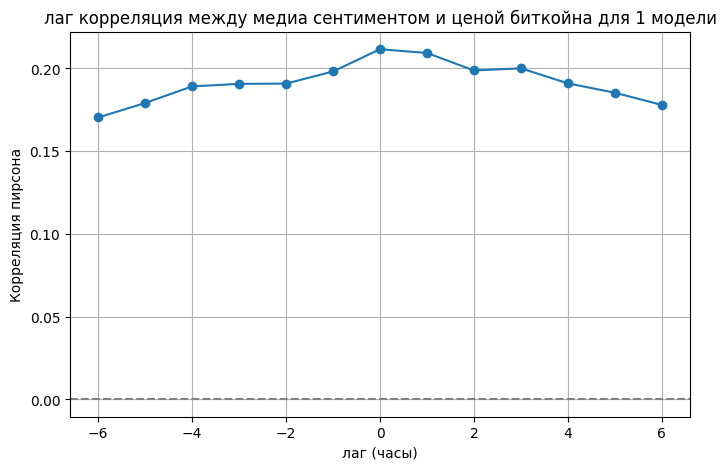

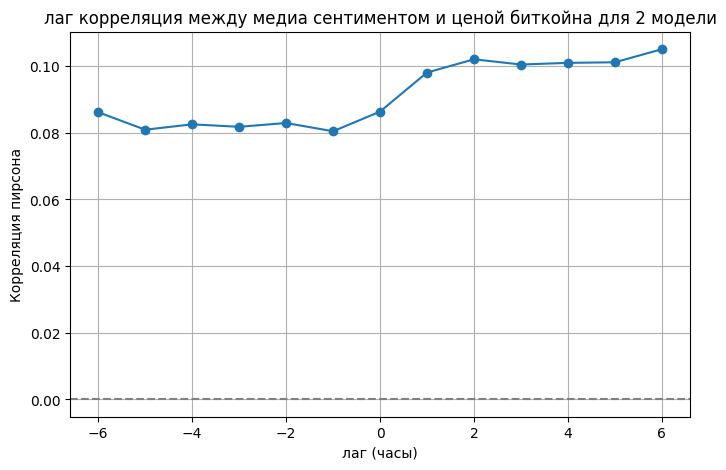

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(lag_corr_1["lag"], lag_corr_1["correlation"], marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("лаг корреляция между медиа сентиментом и ценой биткойна для 1 модели")
plt.xlabel("лаг (часы)")
plt.ylabel("Корреляция пирсона")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lag_corr_2["lag"], lag_corr_2["correlation"], marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("лаг корреляция между медиа сентиментом и ценой биткойна для 2 модели")
plt.xlabel("лаг (часы)")
plt.ylabel("Корреляция пирсона")
plt.grid(True)
plt.show()

In [6]:
from sentence_transformers import SentenceTransformer

news_df["window"] = news_df["publishedAt"].dt.floor("1H")

model = SentenceTransformer('all-MiniLM-L6-v2')
texts = (news_df['text']).tolist()
embeddings = model.encode(texts, batch_size=32, show_progress_bar=True)
news_df['embedding'] = list(embeddings)

emb_df = (
    news_df.groupby("window")["embedding"]
    .apply(lambda x: np.mean(np.vstack(x), axis=0))
    .reset_index()
)
print(emb_df.columns)
print(emb_df.head())

C:\Users\peche\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\peche\AppData\Local\Temp\ipykernel_14100\2295415557.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  news_df["window"] = news_df["publishedAt"].dt.floor("1H")
Batches: 100%|█████████████████████████████████████████████████████████████████████████| 68/68 [01:07<00:00,  1.01it/s]

Index(['window', 'embedding'], dtype='object')
                     window                                          embedding
0 2025-10-02 15:00:00+00:00  [-0.015236772, -0.023428097, -0.011133854, 0.0...
1 2025-10-02 16:00:00+00:00  [-0.011816073, -0.055305984, -0.018895201, 0.0...
2 2025-10-02 17:00:00+00:00  [-0.037489407, -0.020107621, -0.009845415, 0.0...
3 2025-10-02 18:00:00+00:00  [-0.013777616, -0.015273041, -0.016876386, 0.0...
4 2025-10-02 19:00:00+00:00  [-0.007100761, -0.014051303, -0.017381083, 0.0...


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import seaborn as sns

btc.columns = [col[0] if isinstance(col, tuple) else col for col in btc.columns]
btc = btc.rename(columns={"Datetime": "window", "Close": "price"})
print(btc.columns)
print(emb_df.columns)

data = pd.merge(emb_df, btc, on="window", how="inner")
print(len(data))
X = np.vstack(data["embedding"])
Y = data[["price"]].values
X = StandardScaler().fit_transform(X)
Y = StandardScaler().fit_transform(Y.reshape(-1, 1)).ravel()

price_gradient = np.gradient(Y)
pca = PCA(n_components=10)
X_reduced = pca.fit_transform(X)

sentiment_index = X_reduced[:, 0]
data["sentiment"] = sentiment_index
data["price"] = Y
max_lag = 6
results = []

for lag in range(-max_lag, max_lag + 1):
    if lag > 0:
        shifted = data["sentiment"].shift(lag)
        corr, _ = pearsonr(shifted[max_lag:-max_lag], data["price"][max_lag:-max_lag])
    elif lag < 0:
        shifted = data["price"].shift(-lag)
        corr, _ = pearsonr(data["sentiment"][max_lag:-max_lag], shifted[max_lag:-max_lag])
    else:
        corr, _ = pearsonr(data["sentiment"][max_lag:-max_lag], data["price"][max_lag:-max_lag])
    results.append({"lag": lag, "correlation": corr})

lag_corr_df = pd.DataFrame(results)
print(lag_corr_df)

Index(['window', 'price'], dtype='object')
Index(['window', 'embedding'], dtype='object')
234
    lag  correlation
0    -6     0.077701
1    -5     0.071120
2    -4     0.061177
3    -3     0.058325
4    -2     0.061788
5    -1     0.065695
6     0     0.075037
7     1     0.076097
8     2     0.072738
9     3     0.066637
10    4     0.063772
11    5     0.075377
12    6     0.088824


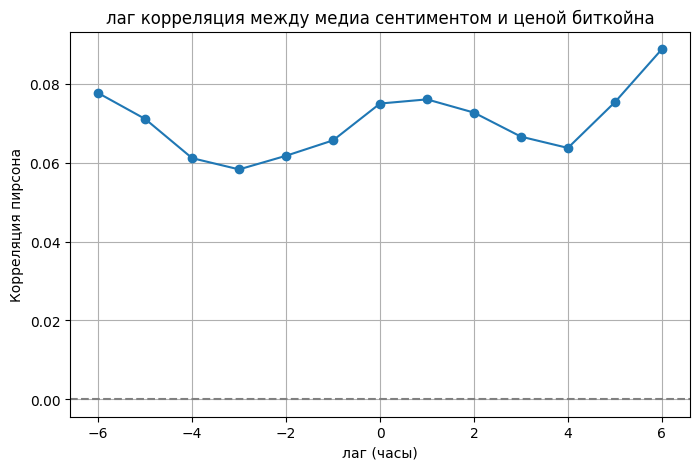

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(lag_corr_df["lag"], lag_corr_df["correlation"], marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("лаг корреляция между медиа сентиментом и ценой биткойна")
plt.xlabel("лаг (часы)")
plt.ylabel("Корреляция пирсона")
plt.grid(True)
plt.show()

In [10]:
max_day_lag = 24
results_2 = []
for lag in range(-max_day_lag, max_day_lag + 1):
    if lag > 0:
        shifted = data["sentiment"].shift(lag)
        corr, _ = pearsonr(shifted[max_day_lag:-max_day_lag], data["price"][max_day_lag:-max_day_lag])
    elif lag < 0:
        shifted = data["price"].shift(-lag)
        corr, _ = pearsonr(data["sentiment"][max_day_lag:-max_day_lag], shifted[max_day_lag:-max_day_lag])
    else:
        corr, _ = pearsonr(data["sentiment"][max_day_lag:-max_day_lag], data["price"][max_day_lag:-max_day_lag])
    results_2.append({"lag": lag, "correlation": corr})

lag_corr_df_2 = pd.DataFrame(results_2)
print(lag_corr_df_2)

    lag  correlation
0   -24     0.033669
1   -23     0.031399
2   -22     0.023780
3   -21     0.020722
4   -20     0.020372
5   -19     0.022514
6   -18     0.026609
7   -17     0.024926
8   -16     0.034879
9   -15     0.047993
10  -14     0.050754
11  -13     0.053149
12  -12     0.057481
13  -11     0.061885
14  -10     0.061782
15   -9     0.060999
16   -8     0.058093
17   -7     0.060300
18   -6     0.059784
19   -5     0.053718
20   -4     0.042853
21   -3     0.040679
22   -2     0.043962
23   -1     0.047809
24    0     0.058052
25    1     0.057066
26    2     0.065376
27    3     0.073239
28    4     0.073782
29    5     0.096958
30    6     0.104784
31    7     0.083308
32    8     0.065899
33    9     0.059761
34   10     0.059932
35   11     0.061974
36   12     0.054922
37   13     0.045744
38   14     0.045865
39   15     0.048298
40   16     0.060704
41   17     0.074716
42   18     0.071995
43   19     0.069325
44   20     0.059755
45   21     0.060888
46   22     0

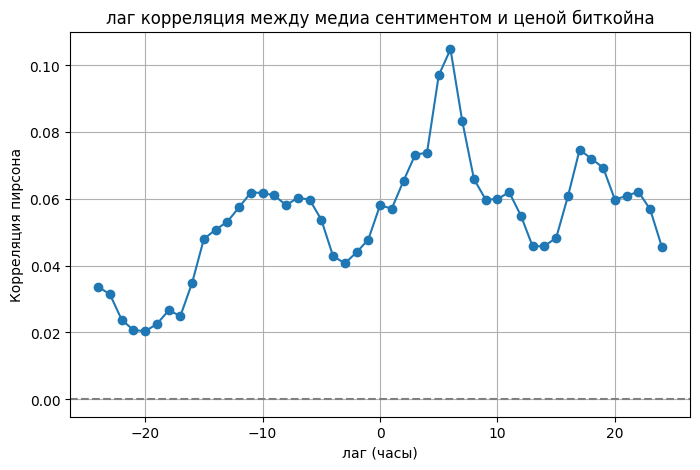

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(lag_corr_df_2["lag"], lag_corr_df_2["correlation"], marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("лаг корреляция между медиа сентиментом и ценой биткойна")
plt.xlabel("лаг (часы)")
plt.ylabel("Корреляция пирсона")
plt.grid(True)
plt.show()